<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 11 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score



# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [3]:
df = pd.read_csv('StudentsPerformance.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [7]:
df.describe

<bound method NDFrame.describe of      gender race/ethnicity parental level of education  ... math score reading score  writing score
0    female        group B           bachelor's degree  ...         72            72             74
1    female        group C                some college  ...         69            90             88
2    female        group B             master's degree  ...         90            95             93
3      male        group A          associate's degree  ...         47            57             44
4      male        group C                some college  ...         76            78             75
..      ...            ...                         ...  ...        ...           ...            ...
995  female        group E             master's degree  ...         88            99             95
996    male        group C                 high school  ...         62            55             55
997  female        group C                 high school  ...       

In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# Step 4: Display PairPlot

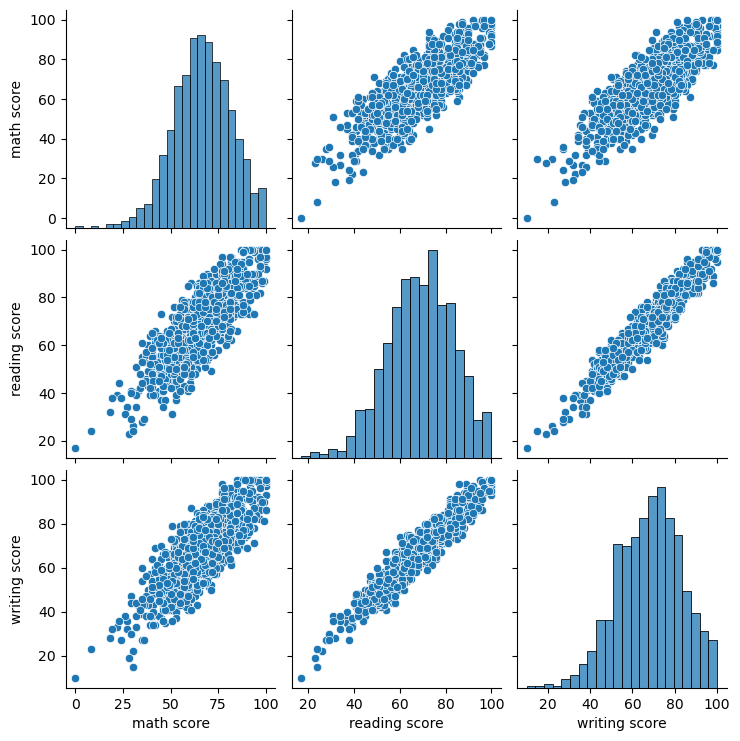

In [13]:
sns.pairplot(df)

# Step 5: Correlation heatmap

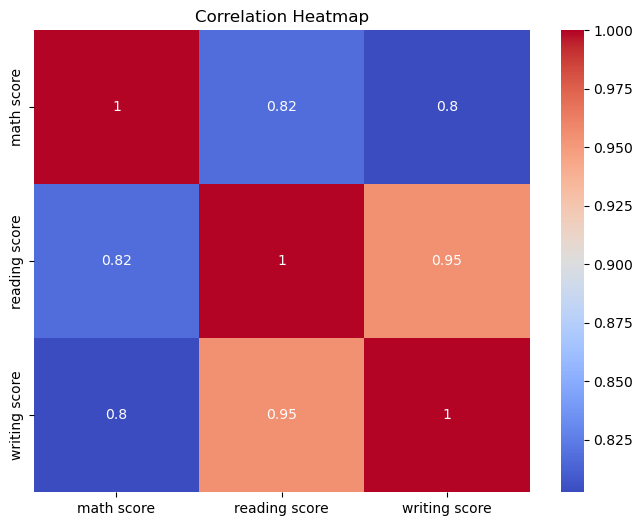

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Step 6: Distribution of numerical features

In [15]:
numeric_df = df[['math score','reading score','writing score']]

In [16]:
numeric_df.head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


# Step 7: Apply StandardScaler

In [18]:
X = numeric_df

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.39002351  0.19399858  0.39149181]
 [ 0.19207553  1.42747598  1.31326868]
 [ 1.57771141  1.77010859  1.64247471]
 [-1.25954302 -0.83389925 -1.58374436]
 [ 0.65395415  0.60515772  0.45733301]]


# Step 8: Elbow method to find optimal k

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows wi

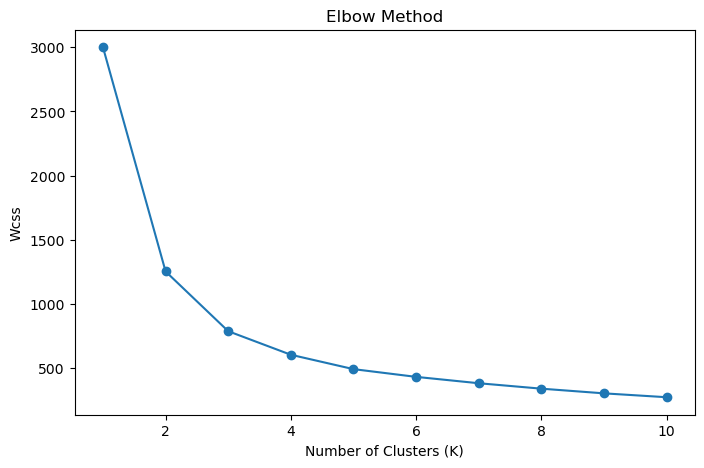

In [26]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Wcss")
plt.title("Elbow Method")
plt.show()


# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [28]:

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df[['math score',
       'reading score',
       'writing score',
       'Cluster']].head()



C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,math score,reading score,writing score,Cluster
0,72,72,74,0
1,69,90,88,2
2,90,95,93,2
3,47,57,44,1
4,76,78,75,2


# Step 10: Print Cluster Center

# Step 11: Plot Cluster

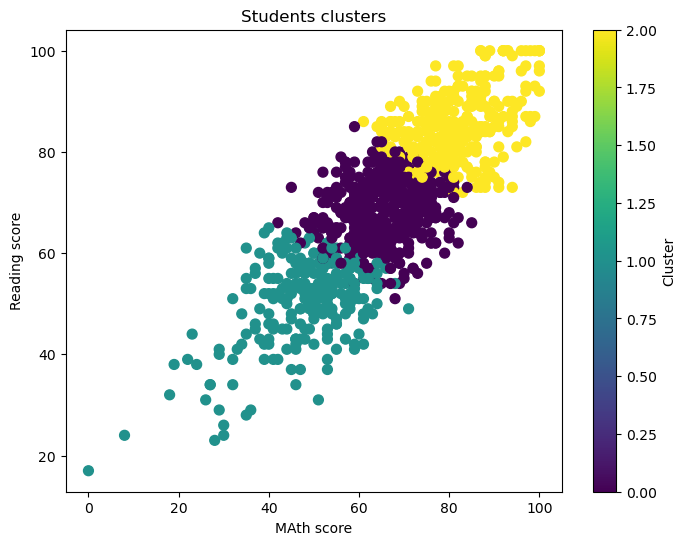

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(df['math score'],
           df['reading score'],
           c=df['Cluster'],
           cmap='viridis',
           s=50)

plt.xlabel("MAth score")
plt.ylabel("Reading score")
plt.title("Students clusters")
plt.colorbar(label="Cluster")
plt.show()

# Step 12:Analyze clusters 

In [30]:
centera = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=['math score', 'reading score', 'writing score']
)

print(cluster_centers)

NameError: name 'centers' is not defined

# Step 13: Perform K-Medoids

# Step:14 Comparison of K-means and K-medoids Clusters

# Step: 15 | USE KMEAN++
